In [24]:
import pysam
import pandas as pd
import numpy as np
import collections
import os
from Bio.Seq import Seq
from Bio.Nexus import Nexus
from Bio import Phylo
import ast
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [25]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    # Get clades in preorder and keep only terminals
    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [26]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12883']='R1b1a1b1a1a2e2'
haplogroups['NA12884']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [27]:
#hprcDF = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HPRC_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_06162025.csv')
#hgsvcDF = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_07162025.csv')
ampliconicDF = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes_noDbGaP.csv')


fec_allDF = ampliconicDF[ampliconicDF['geneCompletenessInfo']=='Full_Exon_Copy'].copy()
#fec_hgsvcDF = hgsvcDF[hgsvcDF['geneCompletenessInfo']=='Full_Exon_Copy'].copy()
#fec_cephDF = cephDF[cephDF['geneCompletenessInfo']=='Full_Exon_Copy'].copy()

combinedDF = fec_allDF.copy()
combinedAllDF = ampliconicDF.copy()
combinedDF.reset_index(inplace=True)
combinedAllDF.reset_index(inplace=True)

In [28]:
combinedDF['CoordinateID']=[str(x)+":"+str(y)+"-"+str(z) for x,y,z in zip(combinedDF['contig'],combinedDF['contigStart'],combinedDF['contigEnd'])]
combinedAllDF['CoordinateID']=[str(x)+":"+str(y)+"-"+str(z) for x,y,z in zip(combinedAllDF['contig'],combinedAllDF['contigStart'],combinedAllDF['contigEnd'])]

In [29]:
from Bio import SeqIO
import re
cdySequences={}
fasta_sequences = SeqIO.parse(open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/PulledSequences/StitchedExons/CDY1.fasta'),'fasta')
for fasta in fasta_sequences:
    name, sequence = fasta.id, str(fasta.seq)
    clean_name = re.split(r"_C_|_\+", name)[0]
    cdySequences[clean_name]='CDY1'

fasta_sequences = SeqIO.parse(open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/PulledSequences/StitchedExons/CDY2.fasta'),'fasta')
for fasta in fasta_sequences:
    name, sequence = fasta.id, str(fasta.seq)
    clean_name = re.split(r"_C_|_\+", name)[0]
    cdySequences[clean_name]='CDY2'

In [30]:
for row in combinedDF.index:
    if 'CDY' in combinedDF.at[row,'geneName']:
        combinedDF.at[row,'geneName'] = cdySequences[combinedDF.at[row,'CoordinateID']]

In [31]:
for row in combinedAllDF.index:
    if 'CDY' in combinedAllDF.at[row,'geneName']:
        combinedAllDF.at[row,'geneName'] = cdySequences[combinedAllDF.at[row,'CoordinateID']]

In [32]:
cdyCheck = combinedDF[combinedDF['geneName'].str.contains("CDY", regex=True)].copy()
collections.Counter(cdyCheck[cdyCheck['geneName']=='CDY2']['MaxLength_Liftoff_ID'])

Counter({'CDY2A': 141, 'CDY2B': 140, 'CDY2B_1': 3, 'CDY1B': 1, 'CDY2B_2': 1})

In [33]:
len(set(combinedDF['sampleName']))

141

In [34]:
sampleOrder=[]
count=0
notfoundList=[]
for x in phylogeneticOrder:
    if x in list(combinedDF['sampleName']):
        if 'HG03456' in x or 'NA12883' in x or 'NA12884' in x:
            continue
        else:
            sampleOrder.append(x)
            count+=1

for x in set(combinedDF['sampleName']):
    if x in phylogeneticOrder:
        continue
    else:
        notfoundList.append(x)
        
for sample in notfoundList:
    continue
    sampleOrder.append(sample)
print(count)

140


In [35]:
notfoundList

['HG03456']

In [36]:
ampliconicGenes = ['BPY2',
 'CDY1','CDY2',
 'DAZ',
 'HSFY1',
 'PRY',
 'RBMY',
 'TSPY',
 'VCY',
 'XKRY']

In [37]:
extraColumns=[]
for gene in ampliconicGenes:
    extraColumns.append(gene+"_extraContigs")

In [38]:
ampliconicSwitch = {'BPY2':'BPY2',
 'CDY1':'CDY1',
 'CDY2':'CDY2',
 'DAZ1':'DAZ',
 'HSFY1':'HSFY1',
 'PRY2':'PRY',
 'RBMY1B':'RBMY',
 'TSPY1':'TSPY',
 'VCY':'VCY',
 'XKRY':'XKRY'}

In [39]:
newCountDF = pd.DataFrame(index=sampleOrder, columns=ampliconicGenes+extraColumns).fillna(0)
newCountDF['MultiContigGenes']='None'

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_3669/1350803388.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  newCountDF = pd.DataFrame(index=sampleOrder, columns=ampliconicGenes+extraColumns).fillna(0)


In [40]:
counts=[]
for sample in set(combinedDF['sampleName']):

    #The current sample dataframe
    testDF = combinedDF[combinedDF['sampleName']==sample].copy()

    if sample == 'HG03456':
        continue
        
        contigs=['HG03456_chrY_1','HG03456_chrY_2']
        
        for contig in contigs:
            testDF2 = testDF[testDF['contig']==contig].copy()
            tempDict = collections.Counter(testDF2[testDF2['contig']==contig]['geneName'])
            mainDict = collections.Counter(testDF2[testDF2['contig']==contig]['geneName'])
            randomDict = collections.Counter(testDF2[~testDF2['contig'].isin(contigs)]['geneName'])
            
            for gene in tempDict.keys():
                geneDF = testDF2[testDF2['geneName']==gene].copy()
                newCountDF.at[contig,ampliconicSwitch[gene]]=tempDict[gene]
                newCountDF.at[contig,str(ampliconicSwitch[gene])+"_extraContigs"]=randomDict[gene]
        
                if len(set(geneDF['contig'])) >1:
                    if newCountDF.at[contig,'MultiContigGenes'] == 'None':
                        newCountDF.at[contig,'MultiContigGenes']=[]
                        newCountDF.at[contig,'MultiContigGenes'].append(ampliconicSwitch[gene])
                    else:
                        newCountDF.at[contig,'MultiContigGenes'].append(ampliconicSwitch[gene])


    else:

        tempDict = collections.Counter(testDF['geneName'])
        
        mainDict = collections.Counter(testDF[testDF['contig']==str(sample)+"_chrY"]['geneName'])
        randomDict = collections.Counter(testDF[testDF['contig']!=str(sample)+"_chrY"]['geneName'])

        for gene in tempDict.keys():
            geneDF = testDF[testDF['geneName']==gene].copy()
            
            newCountDF.at[sample,ampliconicSwitch[gene]]= mainDict[gene]
            newCountDF.at[sample,str(ampliconicSwitch[gene])+"_extraContigs"]= randomDict[gene]
    
            if len(set(geneDF['contig'])) >1:
                if newCountDF.at[sample,'MultiContigGenes'] == 'None':
                    newCountDF.at[sample,'MultiContigGenes']=[]
                    newCountDF.at[sample,'MultiContigGenes'].append(ampliconicSwitch[gene])
                else:
                    newCountDF.at[sample,'MultiContigGenes'].append(ampliconicSwitch[gene])


In [41]:
newCountDF['DYZ19_Count']='None'
newCountDF['DYZ19_ArrayLength']='None'
newCountDF['DYZ19_ArrayPieces']='None'

flaggedDYZ19Samples=[]
directory='/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/dyz19hmmerFilter/'
for file in os.listdir(directory):
    if '.csv' in file:
        if 'HG03456' in file or 'NA12883' in file or 'NA12884' in file:
            continue
        else:
            sample = str(file.split(".")[0])
            if sample in phylogeneticOrder:
                df = pd.read_csv(directory+file)
                if sample == 'HG03456':
                    for row in df.index:
                        newCountDF.at[df.at[row,'Contig'],'DYZ19_Count'] = df.at[row,'Total_DYZ19_Copies']
                        newCountDF.at[df.at[row,'Contig'],'DYZ19_ArrayLength'] = int(df.at[row,'End']) - int(df.at[row,'Start'])
                        newCountDF.at[df.at[row,'Contig'],'DYZ19_ArrayPieces'] = df.at[row,'ArrayBlocks_Combined']
                else:
    
                    if len(df)==1:
                        newCountDF.at[sample,'DYZ19_Count'] = df.iloc[0]['Total_DYZ19_Copies']
                        newCountDF.at[sample,'DYZ19_ArrayLength'] = int(df.iloc[0]['End']) - int(df.iloc[0]['Start'])
                        newCountDF.at[sample,'DYZ19_ArrayPieces'] = df.iloc[0]['ArrayBlocks_Combined']
                    else:
                        flaggedDYZ19Samples.append(sample)
                        newCountDF.at[sample,'DYZ19_Count'] = sum(df['Total_DYZ19_Copies'])
                        newCountDF.at[sample,'DYZ19_ArrayLength'] = sum([int(df.at[row,'End']) - int(df.at[row,'Start']) for row in df.index])
                        newCountDF.at[sample,'DYZ19_ArrayPieces'] = 100

In [42]:
newCountDF['TotalYq12Length'] = 'None'
newCountDF['TotalYq12Length_onlyDYZ1DYZ2']= 'None'
newCountDF['TotalYq12Contigs']= 'None'
newCountDF['TotalDYZ1Arrays']= 'None'
newCountDF['TotalDYZ2Arrays']= 'None'
newCountDF['TotalDYZ1Subunits']= 'None'
newCountDF['TotalDYZ2Subunits']= 'None'
newCountDF['TotalDYZ1Length']= 'None'
newCountDF['TotalDYZ2Length']= 'None'
newCountDF['Yq12_Subunit_Ratio']= 'None'
newCountDF['Yq12_Coordinates']= 'None'
runLengthDict={}
yq12SubunitOrientations=[]
directory='/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter/'
for file in os.listdir(directory):
    
    if '.csv' in file:
        if 'HG03456' in file or 'NA12883' in file or 'NA12884' in file:
            continue
        else:
            sample = str(file.split(".")[0])
            if sample in phylogeneticOrder:
    
                df = pd.read_csv(directory+file)
                df['Length'] = [abs(int(x)-int(y)) for x,y in zip(df['4'], df['3'])]
                subunitInterest=['DYZ1_Yq','DYZ2_Con']
                #break
                if sample == 'HG03456':
                    for contig in set(df['0']):
                        
                        df1 = df[df['0']==contig].copy()
                        df2 = df1[df1['1'].isin(subunitInterest)].copy()
                        
                        
                        totalLength = 0
                        onlyDYZ1DYZ2Length = 0
                        totalContigs=len(set(df['0']))
                
                        totalLength+= max(df1['4']) - min(df1['3'])
                        onlyDYZ1DYZ2Length+= max(df2['4']) - min(df2['3'])
                
                
                        totalDYZ1Blocks = len(df1[df1['1']=='DYZ1_Yq'])
                        totalDYZ2Blocks = len(df1[df1['1']=='DYZ2_Con'])
                        
                        totalDYZ1Units = sum([int(x) for x in df1[df1['1']=='DYZ1_Yq']['5']])
                        totalDYZ2Units = sum([int(x) for x in df1[df1['1']=='DYZ2_Con']['5']])
                
                        totalDYZ1Length = sum([int(x) for x in df1[df1['1']=='DYZ1_Yq']['Length']])
                        totalDYZ2Length = sum([int(x) for x in df1[df1['1']=='DYZ2_Con']['Length']])
                
                        try:
                            newCountDF.at[contig, 'TotalYq12Length'] = totalLength
                            newCountDF.at[contig,'TotalYq12Length_onlyDYZ1DYZ2']= onlyDYZ1DYZ2Length
                            newCountDF.at[contig,'TotalYq12Contigs']= totalContigs
                            newCountDF.at[contig,'TotalDYZ1Arrays']= totalDYZ1Blocks
                            newCountDF.at[contig,'TotalDYZ2Arrays']= totalDYZ2Blocks
                            newCountDF.at[contig,'TotalDYZ1Subunits']= totalDYZ1Units
                            newCountDF.at[contig,'TotalDYZ2Subunits']= totalDYZ2Units
                            newCountDF.at[contig,'TotalDYZ1Length']= totalDYZ1Length
                            newCountDF.at[contig,'TotalDYZ2Length']= totalDYZ2Length
                            newCountDF.at[contig,'Yq12_Subunit_Ratio']= totalDYZ1Units/totalDYZ2Units
                            newCountDF.at[contig,'Yq12_Coordinates']= str(contig)+":"+str(min(df1['3']))+"-"+str(max(df1['4']))
                        except:
                            print(contig, 'ERROR')
    
                else:
                    
                    df2 = df[df['1'].isin(subunitInterest)].copy()
                    subUnitDF = df2[df2['2']=='-'].copy()
                    subUnitDF2 = df2[df2['2']=='+'].copy()
                    orientDF = df2[df2['2'].isin(['-','+'])].copy()
                    newsubunitListtt=[]
                    for row in orientDF.index:
                        if 'DYZ1' in orientDF.at[row,'1']:
                            for i in range(1,int(orientDF.at[row,'5'])+1):
                                newsubunitListtt.append("DYZ1")
                        else:
                            for i in range(1,int(orientDF.at[row,'5'])+1):
                                newsubunitListtt.append("DYZ2")
                    runLengthDict[sample]=newsubunitListtt
                    
                    yq12SubunitOrientations.append([sample, sum(subUnitDF['5'])/(sum(subUnitDF['5'])+sum(subUnitDF2['5'])), sum(subUnitDF2['5'])/(sum(subUnitDF['5'])+sum(subUnitDF2['5']))])
                        
            
                    totalLength = 0
                    onlyDYZ1DYZ2Length = 0
                    totalContigs=len(set(df['0']))
            
                    for contig in set(df['0']):
                        if contig == sample+"_chrY":
                            tempDF = df[df['0']==contig].copy()
                            totalLength+= max(tempDF['4']) - min(tempDF['3'])
                    
                    for contig in set(df2['0']):
                        if contig == sample+"_chrY":
                            tempDF = df2[df2['0']==contig].copy()
                            onlyDYZ1DYZ2Length+= max(tempDF['4']) - min(tempDF['3'])
            
            
                    totalDYZ1Blocks = len(df[df['1']=='DYZ1_Yq'])
                    totalDYZ2Blocks = len(df[df['1']=='DYZ2_Con'])
                    
                    totalDYZ1Units = sum([int(x) for x in df[df['1']=='DYZ1_Yq']['5']])
                    totalDYZ2Units = sum([int(x) for x in df[df['1']=='DYZ2_Con']['5']])
            
                    totalDYZ1Length = sum([int(x) for x in df[df['1']=='DYZ1_Yq']['Length']])
                    totalDYZ2Length = sum([int(x) for x in df[df['1']=='DYZ2_Con']['Length']])
            
                    try:
                        newCountDF.at[sample, 'TotalYq12Length'] = totalLength
                        newCountDF.at[sample,'TotalYq12Length_onlyDYZ1DYZ2']= onlyDYZ1DYZ2Length
                        newCountDF.at[sample,'TotalYq12Contigs']= totalContigs
                        newCountDF.at[sample,'TotalDYZ1Arrays']= totalDYZ1Blocks
                        newCountDF.at[sample,'TotalDYZ2Arrays']= totalDYZ2Blocks
                        newCountDF.at[sample,'TotalDYZ1Subunits']= totalDYZ1Units
                        newCountDF.at[sample,'TotalDYZ2Subunits']= totalDYZ2Units
                        newCountDF.at[sample,'TotalDYZ1Length']= totalDYZ1Length
                        newCountDF.at[sample,'TotalDYZ2Length']= totalDYZ2Length
                        newCountDF.at[sample,'Yq12_Subunit_Ratio']= totalDYZ1Units/totalDYZ2Units
                        newCountDF.at[sample,'Yq12_Coordinates']= str(sample)+"_chrY:"+str(min(df[df['0']==str(sample)+"_chrY"]['3']))+"-"+str(max(df[df['0']==str(sample)+"_chrY"]['4']))
                    except:
                        print(sample, 'ERROR')

In [58]:
#newCountDF[['DYZ19_Count',
       'DYZ19_ArrayLength', 'DYZ19_ArrayPieces', 'TotalYq12Length',
       'TotalYq12Length_onlyDYZ1DYZ2', 'TotalYq12Contigs', 'TotalDYZ1Arrays',
       'TotalDYZ2Arrays', 'TotalDYZ1Subunits', 'TotalDYZ2Subunits',
       'TotalDYZ1Length', 'TotalDYZ2Length', 'Yq12_Subunit_Ratio',
       'Yq12_Coordinates','TSPY_Array_Length']].to_csv("/LeeLab/HPRC/chromosomeY/Data/DYZ17/baseLengths.csv")

In [44]:
newCountDF.columns

Index(['BPY2', 'CDY1', 'CDY2', 'DAZ', 'HSFY1', 'PRY', 'RBMY', 'TSPY', 'VCY',
       'XKRY', 'BPY2_extraContigs', 'CDY1_extraContigs', 'CDY2_extraContigs',
       'DAZ_extraContigs', 'HSFY1_extraContigs', 'PRY_extraContigs',
       'RBMY_extraContigs', 'TSPY_extraContigs', 'VCY_extraContigs',
       'XKRY_extraContigs', 'MultiContigGenes', 'DYZ19_Count',
       'DYZ19_ArrayLength', 'DYZ19_ArrayPieces', 'TotalYq12Length',
       'TotalYq12Length_onlyDYZ1DYZ2', 'TotalYq12Contigs', 'TotalDYZ1Arrays',
       'TotalDYZ2Arrays', 'TotalDYZ1Subunits', 'TotalDYZ2Subunits',
       'TotalDYZ1Length', 'TotalDYZ2Length', 'Yq12_Subunit_Ratio',
       'Yq12_Coordinates', 'TSPY_HMMERHits'],
      dtype='object')

In [20]:
import json

#with open("/LeeLab/HPRC/chromosomeY/Data/Yq12/yq12_architecture_subunit_dict.02262026.json", "w") as f:
#    json.dump(runLengthDict, f)

In [21]:
yq12SubunitDF = pd.DataFrame(data=yq12SubunitOrientations, columns=['sample','antisense','sense'])

In [22]:
#yq12SubunitDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/Yq12/Yq12_subunitInfo.csv")

In [56]:
newCountDF['TSPY_HMMERHits'] = 'None'
newCountDF['TSPY_Array_Length'] = 'None'
directory='/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/tspyhmmerFilter/'
for file in os.listdir(directory):
    if '.csv' in file:
        if 'HG03456' in file or 'NA12883' in file or 'NA12884' in file:
            continue
        else:
            sample = str(file.split(".")[0])
            if sample in phylogeneticOrder:
                df = pd.read_csv(directory+file)
                
                
                if sample == 'HG03456':
                    for contig in set(df['1']):
                        df1 = df[df['1']==contig].copy()
                        newCountDF.at[contig, 'TSPY_HMMERHits'] = len(df1)
                else:
                    newCountDF.at[sample, 'TSPY_HMMERHits'] = len(df)

                    # make a copy
                    x1 = df[df['1']==sample+"_chrY"].copy()
                    
                    # rename for readability if you want
                    x = x1.rename(columns={'5': 'start', '6': 'end'})
                    
                    # sort by coordinate
                    x = x.sort_values(['start', 'end']).reset_index(drop=True)
                    
                    # gap from previous row's end to current row's start
                    x['gap_from_prev'] = x['start'] - x['end'].shift(1)
                    
                    # start a new group when gap is > 50000, or for first row
                    x['group'] = (x['gap_from_prev'].isna() | (x['gap_from_prev'] > 50000)).cumsum()
                    
                    # summarize groups
                    group_sizes = (
                        x.groupby('group')
                         .agg(
                             group_start=('start', 'min'),
                             group_end=('end', 'max'),
                             n_rows=('start', 'size')
                         )
                         .reset_index()
                    )
                    
                    # size of each merged group
                    group_sizes['group_size'] = group_sizes['group_end'] - group_sizes['group_start']
                    newCountDF.at[sample, 'TSPY_Array_Length'] = max(group_sizes['group_size'])

In [57]:
newCountDF

,BPY2,CDY1,CDY2,DAZ,HSFY1,PRY,RBMY,TSPY,VCY,XKRY,...,TotalDYZ1Arrays,TotalDYZ2Arrays,TotalDYZ1Subunits,TotalDYZ2Subunits,TotalDYZ1Length,TotalDYZ2Length,Yq12_Subunit_Ratio,Yq12_Coordinates,TSPY_HMMERHits,TSPY_Array_Length
HG02984,3,2,2,4,2,2,12,31,2,2,...,28,28,4092,3825,14231690,9171378,1.069804,HG02984_chrY:28611692-52531364,33,627766
HG01890,3,2,2,4,2,2,10,34,2,2,...,17,17,3112,2658,10840300,6416096,1.170805,HG01890_chrY:28321276-46042488,36,688778
HG02647,3,2,2,4,2,1,5,39,2,2,...,23,23,4796,3643,16706816,8783829,1.316497,HG02647_chrY:28193560-54209874,41,790290
HG02666,3,2,2,4,2,2,7,39,2,2,...,23,23,4779,3653,16666021,8808031,1.30824,HG02666_chrY:28330194-54329879,41,790285
HG02668,3,2,2,4,2,1,5,39,2,2,...,30,24,4759,3670,16782147,9049674,1.29673,HG02668_chrY:28109640-51459630,41,790285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HG01243,3,2,0,2,2,2,10,30,2,0,...,16,16,2592,2434,9039983,5839284,1.064914,HG01243_chrY:27153198-42576827,32,607381
HG00126,3,2,2,4,2,2,12,29,2,2,...,25,25,3987,4232,13854065,10179765,0.942108,HG00126_chrY:27512192-52083900,31,587050
NA20752,3,2,2,4,2,2,9,29,2,2,...,25,25,3987,4105,13873974,9869734,0.971255,NA20752_chrY:27521957-51785896,31,587136
HG01261,3,2,0,2,2,2,9,30,2,2,...,25,25,3978,4302,13835489,10353582,0.924686,HG01261_chrY:27069723-51802482,32,607368


In [24]:
from scipy import stats

In [25]:
desc = stats.describe([int(x) for x in newCountDF[newCountDF['TotalYq12Contigs']==1]['TotalYq12Length']])

In [26]:
desc

DescribeResult(nobs=np.int64(92), minmax=(np.int64(10342158), np.int64(53147750)), mean=np.float64(27466286.77173913), variance=np.float64(46751389373945.51), skewness=np.float64(0.9503257457020278), kurtosis=np.float64(2.012324011771166))

In [27]:
problem_samples = {x:[] for x in ampliconicGenes}
for sample in newCountDF.index:
    if newCountDF.at[sample,'MultiContigGenes'] == 'None':
        continue
    else:
        for gene in ast.literal_eval(str(newCountDF.at[sample,'MultiContigGenes'])):
            problem_samples[gene].append(sample)

In [28]:
missingGene_samples = {x:[] for x in ampliconicGenes}
extraContig_samples = {x:[] for x in ampliconicGenes}
for sample in newCountDF.index:
    for gene in ampliconicGenes:
        if newCountDF.at[sample,gene] == 0 and newCountDF.at[sample,gene+"_extraContigs"] ==0:
            missingGene_samples[gene].append(sample)
        elif newCountDF.at[sample,gene] == 0 and newCountDF.at[sample,gene+"_extraContigs"] !=0:
            extraContig_samples[gene].append(sample)  
        else:
            continue   

In [29]:
goodColumns=['sampleName', 'hap', 'contig', 'geneName',
       'geneCompletenessInfo', 'totalExons', 'AverageExonDivergence',
       'contigStart', 'contigEnd', 'orientation', 'Exons', 'CallerCount',
       'All_Liftoff_IDs', 'All_Liftoff_Coordinates', 'MaxLength_Liftoff_ID',
       'MaxLength_Liftoff_Coordinates', 'MaxLength_Liftoff_Exons']

In [30]:
#combinedDF[goodColumns].to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_FEC.csv")

In [31]:
#combinedAllDF[goodColumns].to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes.csv")

In [32]:
#combinedAllDF[~combinedAllDF['sampleName'].isin(['NA12883','NA12884'])][goodColumns].to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes_noDbGaP.csv")

In [33]:
#newCountDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes_and_RepeatArrays_LargeTable_Jan072026.csv")

In [34]:
import statistics as stats
import numpy as np
ampliconicGenes = ['BPY2',
 'CDY1','CDY2',
 'DAZ',
 'HSFY1',
 'PRY',
 'RBMY',
 'TSPY',
 'VCY',
 'XKRY']
standardDeviationDict={}
for column in ampliconicGenes:
    standardDeviationDict[column]= stats.stdev([int(x) for x in newCountDF[column]])

ordered_keys = sorted(standardDeviationDict, key=standardDeviationDict.get) 

In [35]:
import pandas as pd

rows = []

for gene in ordered_keys:
    for sample in newCountDF.index:
        color = (
            'purple'
            if ((sample in problem_samples.get(gene, [])) and (sample not in extraContig_samples.get(gene, [])))
            else 'red'
            if ((sample not in problem_samples.get(gene, [])) and (sample in extraContig_samples.get(gene, [])))
            else '#3094cf'
        )

        if newCountDF.at[sample, gene] == 0:
            count = newCountDF.at[sample, gene + '_extraContigs']
        else:
            count = newCountDF.at[sample, gene]

        rows.append({
            "Sample": sample,
            "Gene": gene,
            "Count": count,
            "Color": color
        })

gene_count_color_df1 = pd.DataFrame(rows)

cdy_df = gene_count_color_df1[gene_count_color_df1["Gene"].isin(["CDY1", "CDY2"])]
cdy_sum = (
    cdy_df.groupby("Sample")["Count"]
    .sum()
    .reset_index()
)

cdy_sum["Gene"] = "CDY"
cdy_sum["Color"] = "#3094cf"
cdy_sum = cdy_sum[["Sample","Gene","Count","Color"]]

gene_count_color_df_merged = (
    gene_count_color_df1[~gene_count_color_df1["Gene"].isin(["CDY1","CDY2"])]
    .copy()
)

gene_count_color_df2 = pd.concat(
    [gene_count_color_df_merged, cdy_sum],
    ignore_index=True
)

gene_count_color_df = gene_count_color_df2[gene_count_color_df2['Color']=='#3094cf'].copy()

In [43]:
import collections
newCountDF['TSPY'].describe()

count    140.000000
mean      32.778571
std        5.425848
min       22.000000
25%       29.000000
50%       33.000000
75%       36.000000
max       57.000000
Name: TSPY, dtype: float64

In [38]:
#gene_count_color_df[gene_count_color_df['Gene'].isin(['RBMY', 'TSPY'])].to_csv("/Pille_perSample_Gene_GoodOnly.03102026.csv")

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_10746/3792318283.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax_top, **common_box_kws)
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_10746/3792318283.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax_bottom, **common_box_kws)
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_10746/3792318283.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


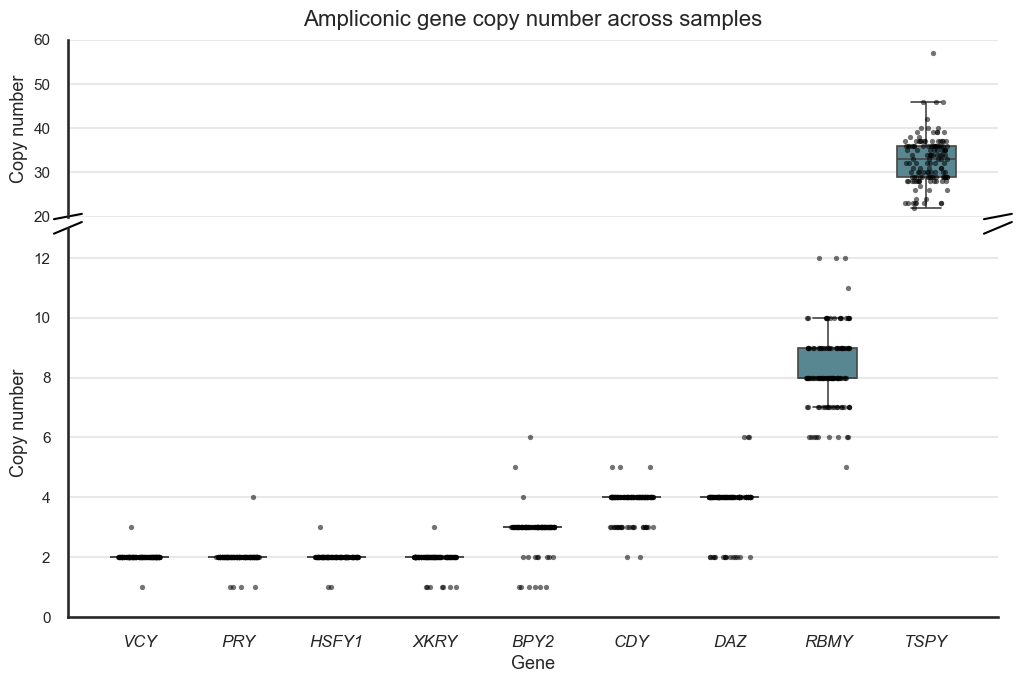

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
sns.set_context("talk", font_scale=0.9)
gene_order = ["VCY", "PRY", "HSFY1", "XKRY", "BPY2", "CDY", "DAZ", "RBMY", "TSPY"]

palette = {
    "VCY":  "#4E8D9C",
    "PRY":  "#4E8D9C",
    "HSFY1":"#4E8D9C",
    "XKRY": "#4E8D9C",
    "BPY2": "#4E8D9C",
    "CDY":  "#4E8D9C",
    "DAZ":  "#4E8D9C",
    "RBMY": "#4E8D9C",
    "TSPY": "#4E8D9C",
}

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(12, 7.5),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 2.2], "hspace": 0.04}
)

common_box_kws = dict(
    data=gene_count_color_df,
    x="Gene",
    y="Count",
    order=gene_order,
    width=0.6,
    showfliers=False,
    linewidth=1.2,
    palette=palette
)

common_strip_kws = dict(
    data=gene_count_color_df,
    x="Gene",
    y="Count",
    order=gene_order,
    color="black",
    size=3.8,
    alpha=0.55,
    jitter=0.22,
    zorder=3
)


sns.boxplot(ax=ax_top, **common_box_kws)
sns.stripplot(ax=ax_top, **common_strip_kws)
sns.boxplot(ax=ax_bottom, **common_box_kws)
sns.stripplot(ax=ax_bottom, **common_strip_kws)


ax_bottom.set_ylim(0, 13)
ax_top.set_ylim(20, 60)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)


ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
ax_top.set_xlabel("")
ax_top.set_ylabel("")
ax_bottom.set_xlabel("Gene", fontsize=13)
ax_bottom.set_ylabel("Copy number", fontsize=13)
ax_top.set_ylabel("Copy number", fontsize=13)

for ax in [ax_top, ax_bottom]:
    ax.yaxis.grid(True, linestyle="-", alpha=0.45)
    ax.xaxis.grid(False)
    ax.tick_params(axis="both", labelsize=11)


d = 0.015
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1.5)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)


ax_top.set_title("Ampliconic gene copy number across samples", fontsize=16, pad=10)
for label in ax_bottom.get_xticklabels():
    label.set_fontstyle("italic")
    label.set_fontsize(12)
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/Ampliconic_gene_copy_number_boxplot.03102026.pdf", bbox_inches="tight")
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/Ampliconic_gene_copy_number_boxplot.03102026.jpeg", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

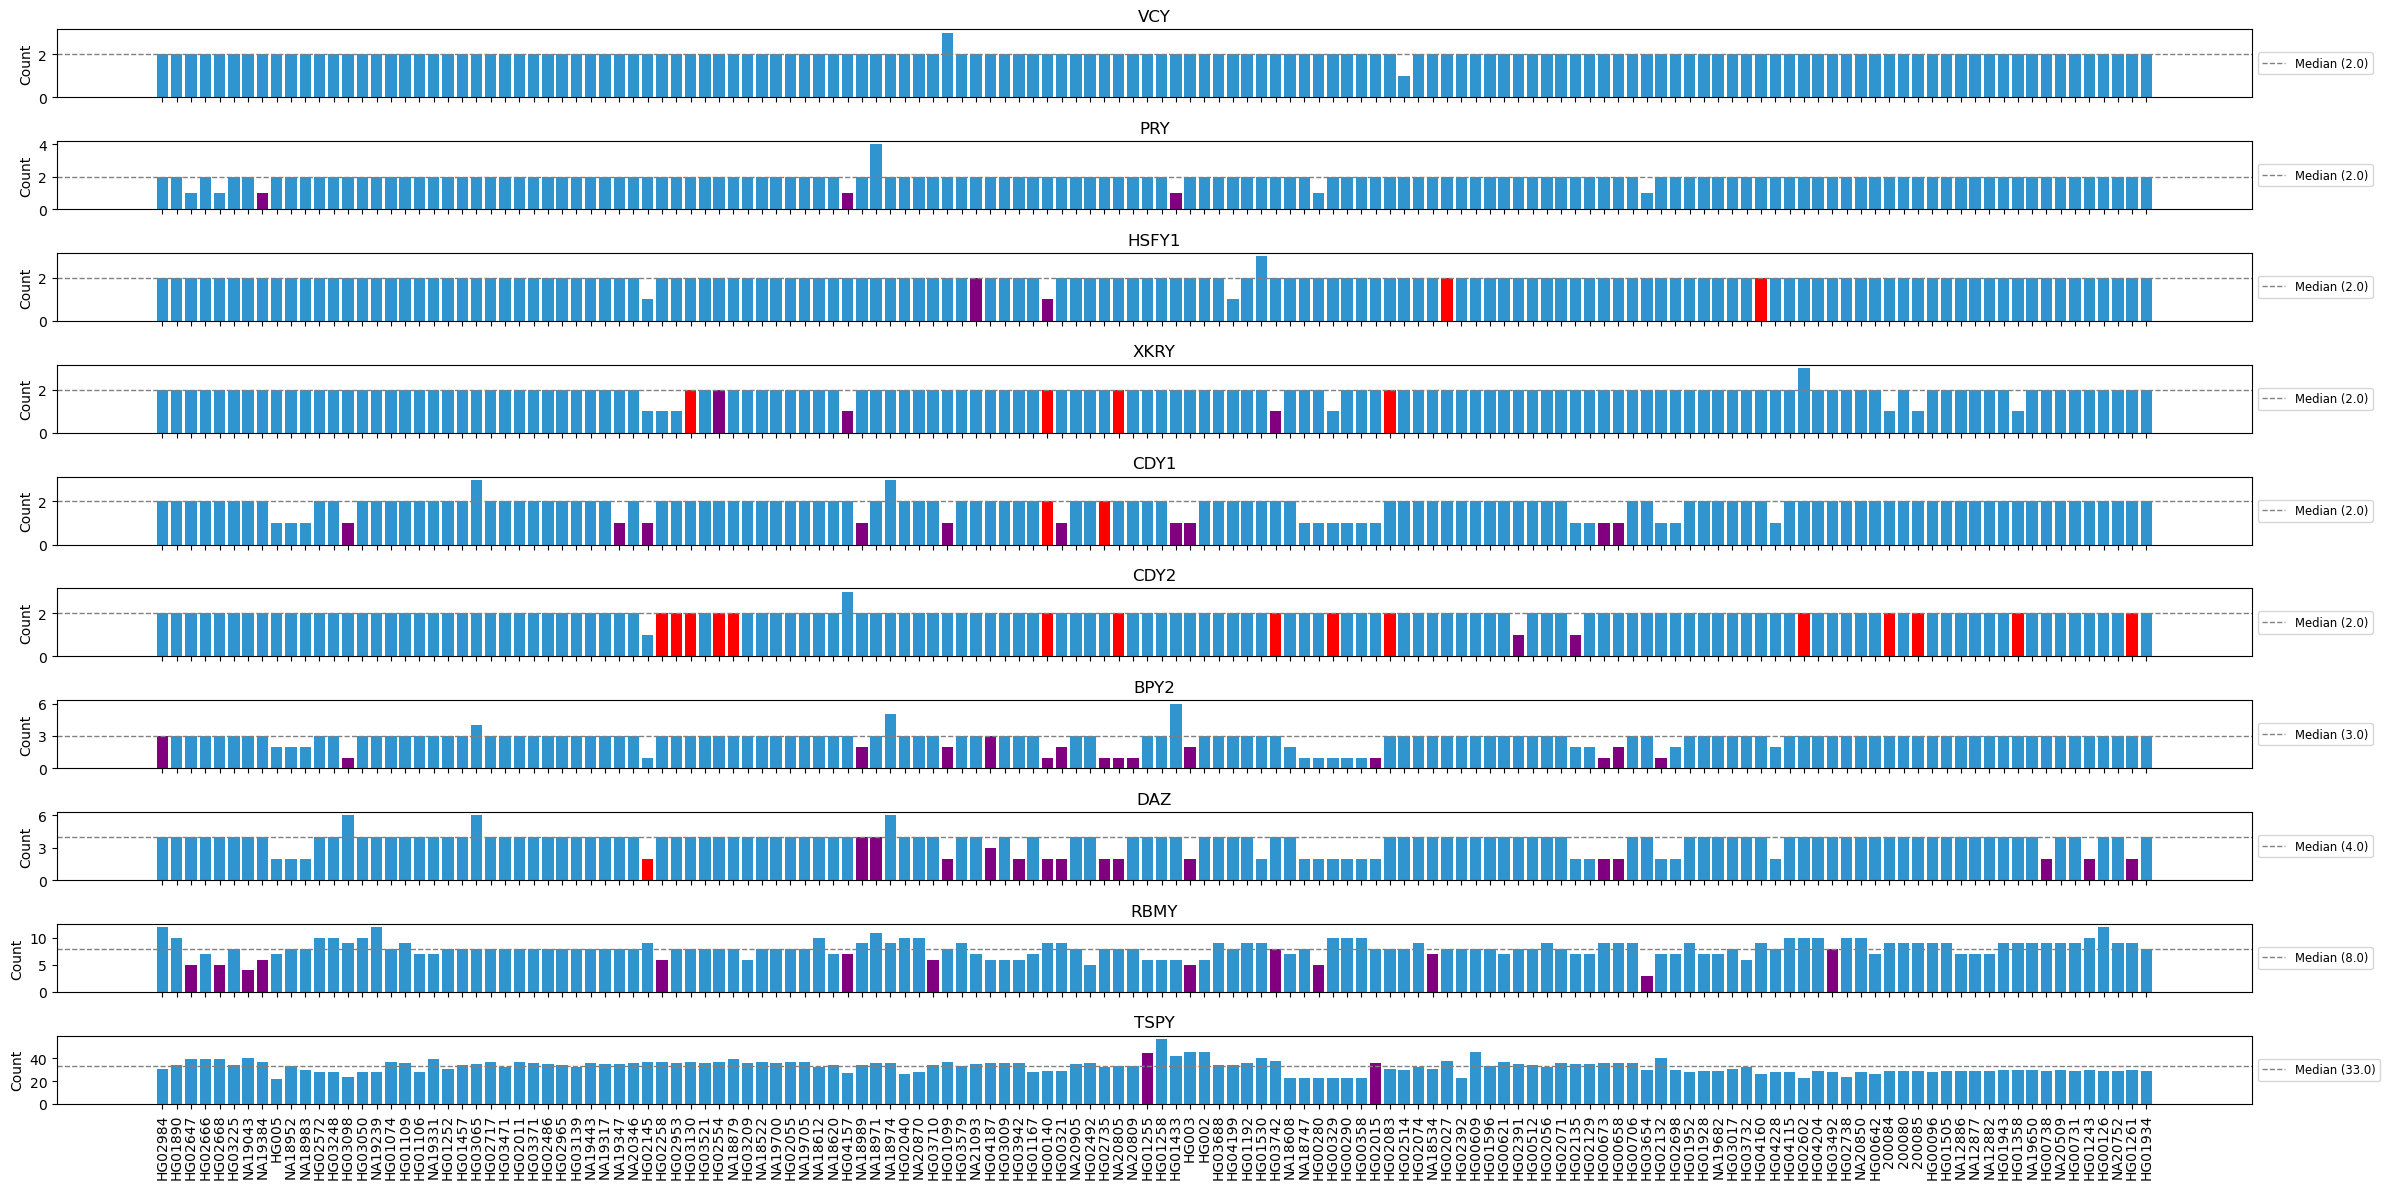

In [47]:
fig, axes = plt.subplots(10, 1, figsize=(24, 12), sharex=True)
axes = axes.flatten()

for i, gene in enumerate(ordered_keys):
    ax = axes[i]
    colors = ['purple' if ((sample in problem_samples.get(gene, [])) and (sample not in extraContig_samples.get(gene, []))) else 'red' if ((sample not in problem_samples.get(gene, [])) and (sample in extraContig_samples.get(gene, []))) else '#3094cf' for sample in newCountDF.index]
    counts=[]
    for sample in newCountDF.index:
        if newCountDF.at[sample,gene]==0:
            counts.append(newCountDF.at[sample,gene+'_extraContigs'])
        else:
             counts.append(newCountDF.at[sample,gene])

    
    ax.bar(newCountDF.index, counts, color=colors)
    ax.set_title(gene)
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(newCountDF.index)))
    ax.set_xticklabels(newCountDF.index, rotation=90)
    avg = np.median(counts)
    ax.axhline(avg, color='grey', linestyle='--', linewidth=1, label=f'Median ({avg:.1f})')
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))
    
for j in range(i+1, 9):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/AmpliconicGene_barplots.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/AmpliconicGene_barplots.jpeg", dpi=500, format='jpeg', bbox_inches='tight')

plt.show()

In [48]:
NcontainingSamples=["HG01109_chrY", "HG02132_chrY", "HG03742_chrY","HG00673_chrY","HG02015_chrY","NA19317_chrY","HG02668_chrY","NA19384_chrY",
                    "NA18952_chrY","HG03688_chrY", "HG01358_chrY","NA20346_chrY","NA19239_chrY","NA19347_chrY","HG01099_chrY",
                    "HG00321_chrY","HG04157_chrY","HG03942_chrY","HG02965_chrY","HG005_chrY","NA18612_chrY","NA19443_chrY","NA18534_chrY",
                    "HG00096_chrY","HG03654_chrY","HG00706_chrY","NA12883_chrY","NA18974_chrY","HG03130_chrY","HG01192_chrY","HG003_chrY",
                    "HG02129_chrY","NA19700_chrY","HG02083_chrY","HG01433_chrY","HG03492_chrY","NA18989_chrY","NA20509_chrY",
                    "HG03139_chrY","HG03521_chrY","HG04115_chrY","HG01457_chrY","HG03371_chrY","NA18620_chrY","HG00329_chrY","HG00658_chrY"]
print(len(NcontainingSamples), 143-len(NcontainingSamples))

46 97


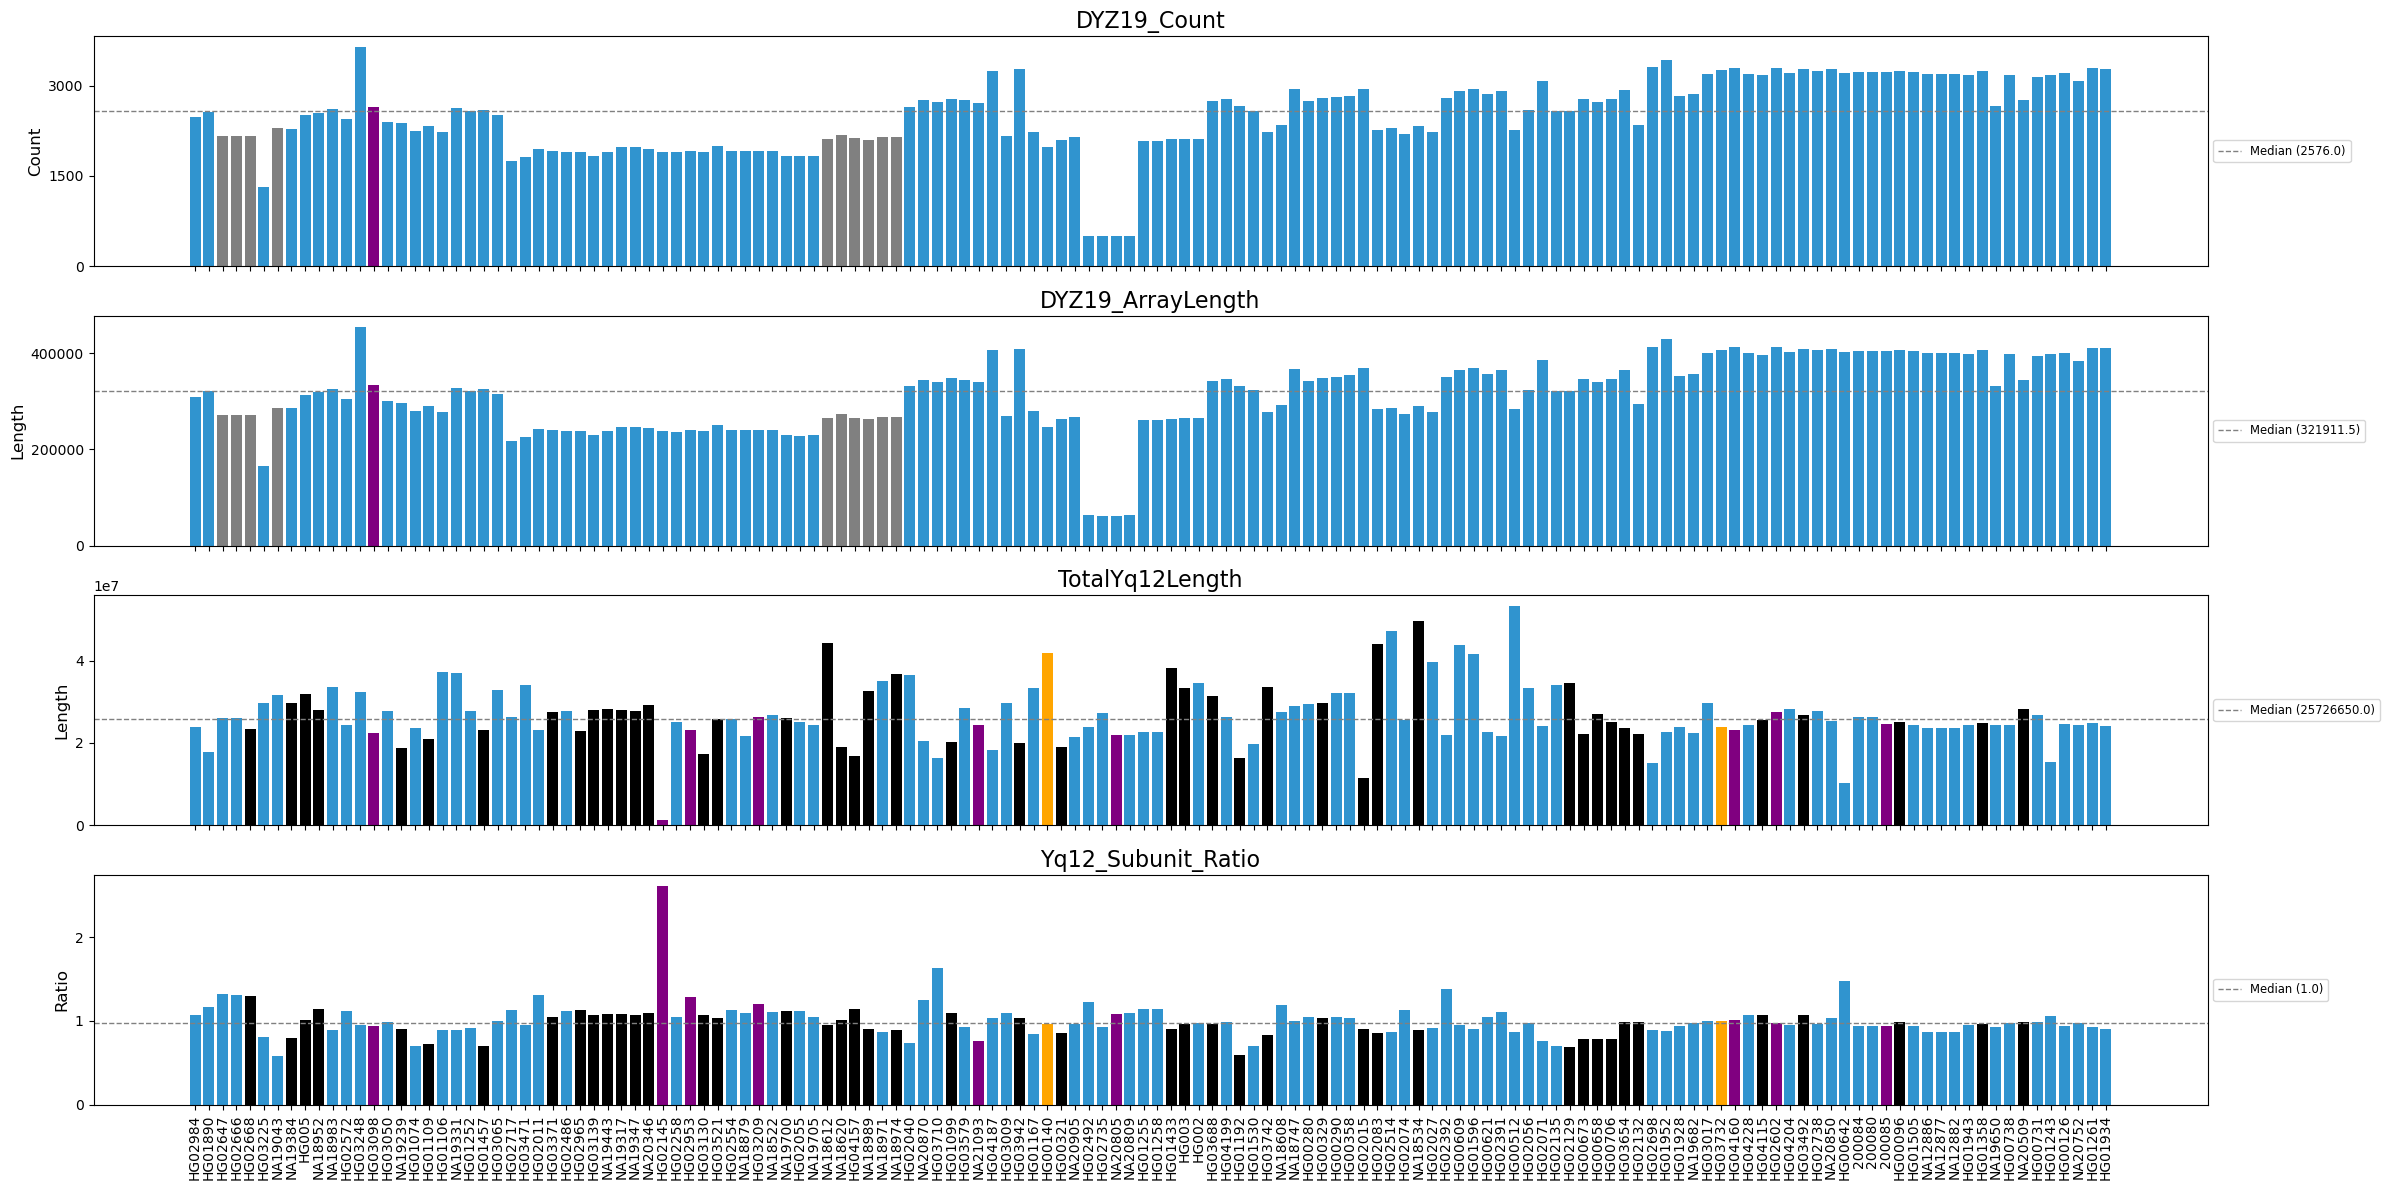

In [47]:
ampliconicGenes=['DYZ19_Count', 'DYZ19_ArrayLength','TotalYq12Length','Yq12_Subunit_Ratio']
ampliconicGenes2=['Yq12_Subunit_Ratio']
qcCalledYq12Regions = ['HG03732_chrY', 'HG00140_chrY']

standardDeviationDict={}
for column in ampliconicGenes:
    standardDeviationDict[column]= stats.stdev([int(x) for x in newCountDF[column]])

ordered_keys = sorted(standardDeviationDict, key=standardDeviationDict.get) 

problem_samples = {x:[] for x in ampliconicGenes}
problem_samples2 = {x:[] for x in ampliconicGenes}
for sample in newCountDF.index:
    for gene in ampliconicGenes:
        if 'DYZ19' in gene:
            if newCountDF.at[sample,'DYZ19_ArrayPieces']>1:
                problem_samples2[gene].append(sample)
            else:
                continue
        else:
            if newCountDF.at[sample,'TotalYq12Contigs']>1:
                problem_samples[gene].append(sample)
            else:
                continue

fig, axes = plt.subplots(4, 1, figsize=(24, 12), sharex=True)
axes = axes.flatten()

for i, gene in enumerate(ampliconicGenes):
    if 'Length' in gene:
        yaxisVariable = 'Length'
    elif 'Ratio' in gene:
        yaxisVariable = 'Ratio'
    else:
        yaxisVariable = 'Count'
    ax = axes[i]
    counts = newCountDF[gene]
    if 'DYZ19' in gene:
        colors = []
        for sample in newCountDF.index:
            if sample in problem_samples2[gene]:
                if sample in flaggedDYZ19Samples:
                    colors.append('purple')
                else:
                    colors.append('grey')

            else:
                colors.append('#3094cf')
    else:
        colors = [
    'purple' if (sample in problem_samples.get(gene, []) and sample+"_chrY" not in NcontainingSamples)
    else 'black' if sample+"_chrY" in NcontainingSamples
    else 'orange' if sample+"_chrY" in qcCalledYq12Regions
    else '#3094cf'
    for sample in newCountDF.index
]
    ax.bar(newCountDF.index, counts, color=colors)
    ax.set_title(gene, fontsize=16)
    ax.set_ylabel(yaxisVariable,fontsize=12)
    ax.set_xticks(range(len(newCountDF.index)))
    ax.set_xticklabels(newCountDF.index, rotation=90)
    avg = counts.median()
    ax.axhline(avg, color='grey', linestyle='--', linewidth=1, label=f'Median ({avg:.1f})')
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))
    
for j in range(i+1, 4):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DYZ19_Yq12_barplots_Jan162026.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/DYZ19_Yq12_barplots_Jan162026.jpeg", dpi=500, format='jpeg', bbox_inches='tight')
plt.show()

In [157]:
newCountDF2 = newCountDF.loc[[x for x in newCountDF.index if x not in problem_samples['Yq12_Subunit_Ratio']]].copy()

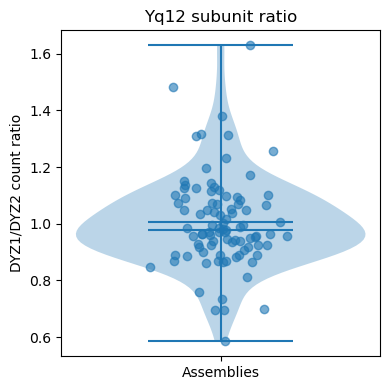

In [158]:
fig, ax = plt.subplots(figsize=(4,4))
ax.violinplot([float(x) for x in newCountDF2['Yq12_Subunit_Ratio']], showmeans=True, showmedians=True)

x = np.random.normal(1, 0.04, size=len([float(x) for x in newCountDF2['Yq12_Subunit_Ratio']]))
ax.scatter(x, [float(x) for x in newCountDF2['Yq12_Subunit_Ratio']], alpha=0.6)

ax.set_xticks([1])
ax.set_xticklabels(["Assemblies"])
ax.set_ylabel("DYZ1/DYZ2 count ratio")
ax.set_title("Yq12 subunit ratio")

plt.tight_layout()
plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Yq12_ratio_violin.pdf", format='pdf', bbox_inches='tight')
plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Yq12_ratio_violin.jpeg", dpi=500, format='jpeg', bbox_inches='tight')
plt.show()

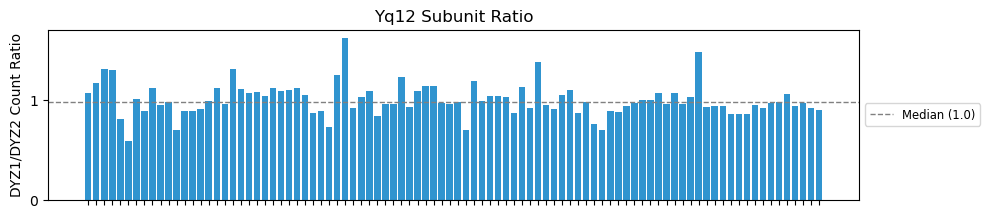

In [159]:
ampliconicGenes=['DYZ19_Count', 'DYZ19_ArrayLength','TotalYq12Length','Yq12_Subunit_Ratio']
ampliconicGenes2=['Yq12_Subunit_Ratio']

problem_samples = {x:[] for x in ampliconicGenes}
problem_samples2 = {x:[] for x in ampliconicGenes}
for sample in newCountDF2.index:
    for gene in ampliconicGenes:
        if 'DYZ19' in gene:
            if newCountDF2.at[sample,'DYZ19_ArrayPieces']>1:
                problem_samples2[gene].append(sample)
            else:
                continue
        else:
            if newCountDF2.at[sample,'TotalYq12Contigs']>1:
                problem_samples[gene].append(sample)
            else:
                continue
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
axes = axes.flatten()

for i, gene in enumerate(ampliconicGenes2):
    ax = axes[i]
    counts = newCountDF2[gene]
    colors = ['red' if sample in problem_samples.get(gene, []) else '#3094cf' for sample in newCountDF2.index]
    ax.bar(newCountDF2.index, counts, color=colors)
    ax.set_title('Yq12 Subunit Ratio')
    ax.set_ylabel('DYZ1/DYZ2 Count Ratio')
    ax.set_xticks(range(len(newCountDF2.index)))
    ax.set_xticklabels(newCountDF2.index, rotation=90)
    avg = counts.median()
    ax.axhline(avg, color='grey', linestyle='--', linewidth=1, label=f'Median ({avg:.1f})')
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))
    
for j in range(i+1, 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Yq12_ratio_large.pdf", format='pdf', bbox_inches='tight')
plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Yq12_ratio_large.jpeg", dpi=500, format='jpeg', bbox_inches='tight')
plt.show()